# **Step 1 — Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Use it to work with folders and files.
import os
# Working with .zip files.
import zipfile

# **Step 2 — Load Dataset From Kaggel**

In [ ]:
# 1. Set your Kaggle API token
os.environ['KAGGLE_KEY'] = 'Kaggel_API_HERE'

# 2. Install Kaggle CLI
!pip install -q kaggle

# 3. Download the Chest X-Ray dataset directly
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 4. Unzip the dataset into Colab
print("Extracting files...")
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('chest_xray_data')

print("Done! Dataset extracted to 'chest_xray_data'")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting files...
Done! Dataset extracted to 'chest_xray_data'


# **Step 3 — Explore Dataset**

In [ ]:
# It means Show me everything inside chest_xray_data folder
os.listdir("/content/chest_xray_data")

In [ ]:
# It means Show me everything inside the chest_xray folder.
print(os.listdir("/content/chest_xray_data/chest_xray"))

In [ ]:
# It means Show me what's inside the train folder.
print(os.listdir("/content/chest_xray_data/chest_xray/train"))

['NORMAL', 'PNEUMONIA']


# **Step 4 — Visualize Images**

In [ ]:
from PIL import Image

**Normal Image**

In [ ]:
path = "/content/chest_xray_data/chest_xray/train/NORMAL"

In [ ]:
image = os.listdir(path)[0]
img = Image.open(path + "/"+ image)

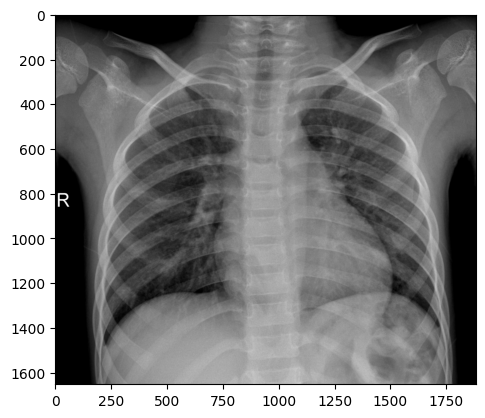

In [ ]:
plt.imshow(img, cmap = "gray")
plt.show()

**PNEUMONIA Image**

In [ ]:
path = "/content/chest_xray_data/chest_xray/train/PNEUMONIA"

In [ ]:
image = os.listdir(path)[0]
img = Image.open(path + "/" + image)

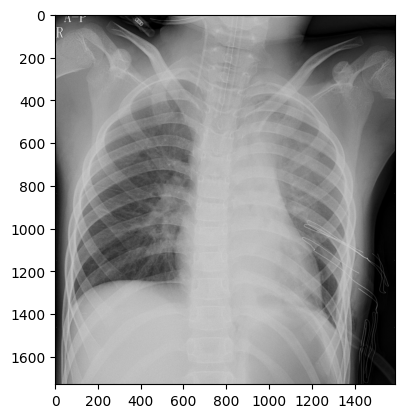

In [ ]:
plt.imshow(img, cmap = "gray")
plt.show()

# **Step 5 — Load Dataset Into Tensorflow**

In [ ]:
import tensorflow as tf

**Load Train Data**

In [ ]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/chest_xray_data/chest_xray/train",
    image_size = (150,150),
    batch_size = 32
)

Found 5216 files belonging to 2 classes.


In [ ]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

**Load Validation Data**

In [ ]:
val_data = tf.keras.utils.image_dataset_from_directory(
    "/content/chest_xray_data/chest_xray/val",
    image_size = (150,150),
    batch_size = 32
)

Found 16 files belonging to 2 classes.


In [ ]:
val_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

**Load Test Data**

In [ ]:
test_data = tf.keras.utils.image_dataset_from_directory(
   "/content/chest_xray_data/chest_xray/test",
    image_size = (150,150),
    batch_size = 32
)

Found 624 files belonging to 2 classes.


In [ ]:
test_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

# **Step 6 — Visualize the Dataset**

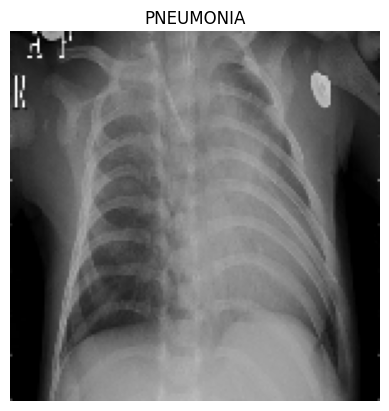

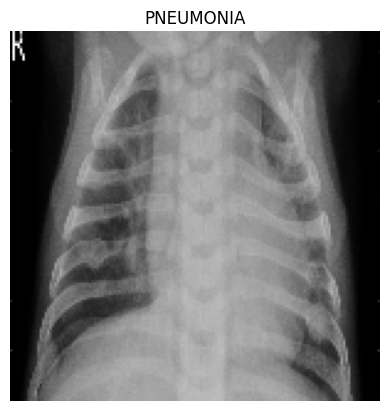

In [ ]:
class_names = ["NORMAL", "PNEUMONIA"]

for images, labels in train_data.take(2):
  plt.imshow(images[0].numpy().astype("uint8"))
  plt.title(class_names[labels[0].numpy()])
  plt.axis("off")
  plt.show()


# **Step 7 — Normalize Images**

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [ ]:
train_data = train_data.map(lambda x,y: (normalization_layer(x),y))

In [ ]:
test_data = test_data.map(lambda x,y: (normalization_layer(x),y))

In [ ]:
val_data = val_data.map(lambda x,y: (normalization_layer(x),y))

# **Data Augmentation**

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# **Step 8 — Build the CNN Model**

In [ ]:
model_CNN = tf.keras.Sequential(
    [
        tf.keras.layers.Conv2D(32, (3,3), activation = 'relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Conv2D(64, (3,3), activation = 'relu'),
        tf.keras.layers.MaxPooling2D(2,2),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation = 'relu'),
        tf.keras.layers.Dropout(0.5),

        tf.keras.layers.Dense(1, activation="sigmoid")
    ]
)

# **Step 9 — Compile the CNN**

In [ ]:
model_CNN.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# **Step 10 — Train the CNN**

In [ ]:
history = model_CNN.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 177ms/step - accuracy: 0.8938 - loss: 0.2790 - val_accuracy: 0.8750 - val_loss: 0.3401
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - accuracy: 0.9523 - loss: 0.1294 - val_accuracy: 0.6250 - val_loss: 0.9288
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 178ms/step - accuracy: 0.9640 - loss: 0.0949 - val_accuracy: 0.8750 - val_loss: 0.3134
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - accuracy: 0.9711 - loss: 0.0830 - val_accuracy: 0.8750 - val_loss: 0.2727
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 186ms/step - accuracy: 0.9801 - loss: 0.0552 - val_accuracy: 0.9375 - val_loss: 0.1060
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 183ms/step - accuracy: 0.9795 - loss: 0.0526 - val_accuracy: 0.8750 - val_loss: 0.2728
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.9837 - loss: 0.0421 - val_accuracy: 0.8750 - val_loss: 0.2381
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 29s 180ms/step - accuracy: 0.9902 - loss: 0

**Identifying Class Weights**

In [ ]:
from sklearn.utils import class_weight

y_train = []

for images, labels in train_data:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


**Again Model Train using Class Weights**

In [ ]:
history = model_CNN.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 192ms/step - accuracy: 0.9866 - loss: 0.0400 - val_accuracy: 0.9375 - val_loss: 0.0577
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.9898 - loss: 0.0280 - val_accuracy: 0.9375 - val_loss: 0.1888
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 225ms/step - accuracy: 0.9918 - loss: 0.0225 - val_accuracy: 0.9375 - val_loss: 0.1375
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 192ms/step - accuracy: 0.9889 - loss: 0.0299 - val_accuracy: 0.9375 - val_loss: 0.1086
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 198ms/step - accuracy: 0.9923 - loss: 0.0214 - val_accuracy: 0.9375 - val_loss: 0.2199
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.9935 - loss: 0.0204 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 186ms/step - accuracy: 0.9964 - loss: 0.0121 - val_accuracy: 1.0000 - val_loss: 0.0340
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 30s 186ms/step - accuracy: 0.9942 - loss: 0

# **Step 11 — Model Evaluation**

In [ ]:
test_loss, test_accuracy = model_CNN.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.7821 - loss: 1.8460
Test Loss: 1.8460122346878052
Test Accuracy: 0.7820512652397156


In [ ]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model_CNN.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[101 133]
 [  3 387]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.97      0.43      0.60       234
   PNEUMONIA       0.74      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.72       624
weighted avg       0.83      0.78      0.76       624



# **Step 12 — Model Visualization**

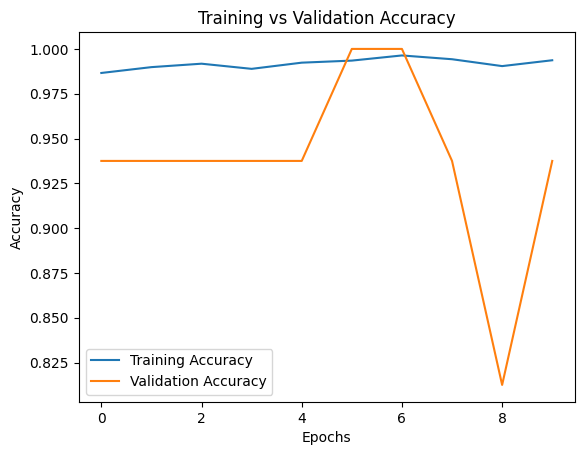

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

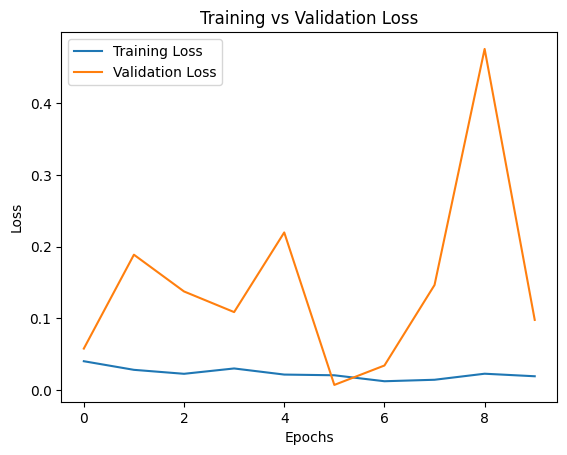

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()